# Hands-On Exercise 2.2:
# Exploring Data in Python in Preparation for Analysis
***

## Objectives

### In this exercise, you will familiarize yourself with Python syntax commands for exploring data sets in Python.

### Overview
In this exercise, you will use Python commands to look at data distributions and how
visualization can aid in this process.<br><br>

**Pre-step: Execute the following cell in order to suppress warning messages**

In [1]:
import warnings 
warnings.filterwarnings("ignore")

**Major Step 1: Querying from data sets**

1. ❏ Import the **pandas** and **statsmodels.api** libraries

In [2]:
import pandas as pd
import statsmodels.api as sm

2. ❏ Import a dataset called **mtcars** and preview it<br><br>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;*Syntax:* &nbsp;&nbsp;&nbsp; ***mtcars = sm.datasets.get_rdataset("mtcars").data***

In [3]:
mtcars = sm.datasets.get_rdataset("mtcars").data
mtcars.head()

,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
rownames,,,,,,,,,,,
Mazda RX4,21.0,6,160.0,110,3.90,2.620,16.46,0,1,4,4
Mazda RX4 Wag,21.0,6,160.0,110,3.90,2.875,17.02,0,1,4,4
Datsun 710,22.8,4,108.0,93,3.85,2.320,18.61,1,1,4,1
Hornet 4 Drive,21.4,6,258.0,110,3.08,3.215,19.44,1,0,3,1
Hornet Sportabout,18.7,8,360.0,175,3.15,3.440,17.02,0,0,3,2


3. ❏ Calculate the **mean** of the cars' mpg.

In [4]:
mtcars['mpg'].mean()

20.090625000000003

4. ❏ Calculate the **median** of the cars' mpg.

In [5]:
mtcars['mpg'].median()

19.2

5. ❏ Calculate the **standard deviation** and **variance** of the mpg.

In [6]:
mtcars['mpg'].std()

6.026948052089105

In [7]:
mtcars['mpg'].var()

36.32410282258065

6. ❏ Display a **distribution summary** of numeric data in the mtcars data set using the **.describe()** method

In [8]:
mtcars.describe()

,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
count,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.0000
mean,20.090625,6.187500,230.721875,146.687500,3.596563,3.217250,17.848750,0.437500,0.406250,3.687500,2.8125
std,6.026948,1.785922,123.938694,68.562868,0.534679,0.978457,1.786943,0.504016,0.498991,0.737804,1.6152
min,10.400000,4.000000,71.100000,52.000000,2.760000,1.513000,14.500000,0.000000,0.000000,3.000000,1.0000
25%,15.425000,4.000000,120.825000,96.500000,3.080000,2.581250,16.892500,0.000000,0.000000,3.000000,2.0000
50%,19.200000,6.000000,196.300000,123.000000,3.695000,3.325000,17.710000,0.000000,0.000000,4.000000,2.0000
75%,22.800000,8.000000,326.000000,180.000000,3.920000,3.610000,18.900000,1.000000,1.000000,4.000000,4.0000
max,33.900000,8.000000,472.000000,335.000000,4.930000,5.424000,22.900000,1.000000,1.000000,5.000000,8.0000


**Major Step 2: Visualizing data**

7. ❏ Import the **matplotlib.pyplot** library. Give it an alias of *plt*

In [9]:
import matplotlib.pyplot as plt

8. ❏ Use a *ggplot* style using the following command:<br>
```python
plt.style.use('ggplot')```

In [10]:
plt.style.use('ggplot')

9. ❏ Generate a **histogram** of the cars' mpg

<Axes: >

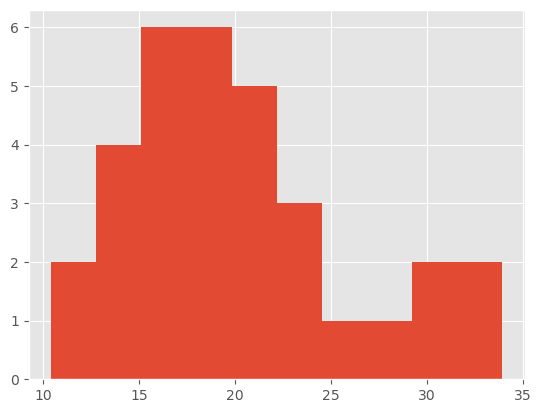

In [11]:
mtcars['mpg'].hist()

10. ❏ Display **box plots** of the third and fourth columns of *mtcars*

In [27]:
# Assuming 'df' is your DataFrame and 'column_name' is the column to filter
Q1 = mtcars['hp'].quantile(0.25)
Q3 = mtcars['hp'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_filtered = mtcars[(mtcars['hp'] >= lower_bound) & (mtcars['hp'] <= upper_bound)]
df_outlier =  mtcars[(mtcars['hp'] < lower_bound) | (mtcars['hp'] > upper_bound)]

df_outlier

,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb,z_score
rownames,,,,,,,,,,,,
Maserati Bora,15.0,8,301.0,335,3.54,3.57,14.6,0,1,5,8,2.790515


In [24]:
mtcars['hp'].max()

335

<Axes: >

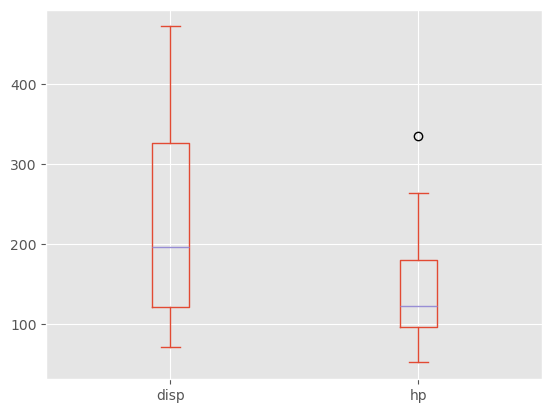

In [12]:

mtcars.iloc[:,[2,3]].plot(kind='box')

11. ❏ Display a count of the number of observations of gears using a **bar chart** for possible values of categorical variable<br><br>
*Hint: Use the **.value_counts()** method on the gear column to get a count of the observations*

In [18]:
mtcars['gear'].value_counts()

gear
3    15
4    12
5     5
Name: count, dtype: int64

<Axes: ylabel='count'>

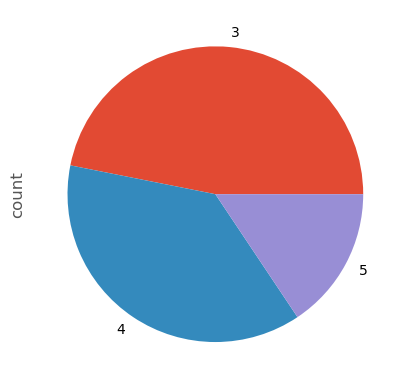

In [28]:
mtcars['gear'].value_counts().plot(kind='pie')

## <center>**Congratulations! You have successfully explored various data sets within Python.**</center>

 <center>
 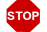
 </center>

# <center>**This is the end of the exercise.**</center>

In [14]:
%pip install sparklines

Note: you may need to restart the kernel to use updated packages.


In [16]:
import numpy as np
from sparklines import sparklines

# 1. Generate Descriptive Statistics
desc_df = mtcars.describe()

# 2. Define a Sparkline Function
def sparkline_dist(data):
    hist = np.histogram(data, bins=10)[0]
    dist_strings = ''.join(sparklines(hist))
    return dist_strings

# 3. Apply to the Descriptive Statistics
sparkline_data = {}
for col in mtcars.columns:
    sparkline_data[col] = sparkline_dist(mtcars[col])

# Create a Series of sparklines to add to desc_df
sparkline_series = pd.Series(sparkline_data, name='Sparkline')

# Add the sparkline column to the descriptive statistics DataFrame
desc_df.loc['sparkline'] = sparkline_series

# 4. Display with Styling
desc_df.style.format('{:.2f}', subset=pd.IndexSlice[['mean', 'std', 'min', '25%', '50%', '75%', 'max'], :]) \
            .set_caption('Descriptive Statistics with Sparklines') \
            .set_properties(padding="15px", border='1px solid grey')


,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
count,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000
mean,20.09,6.19,230.72,146.69,3.60,3.22,17.85,0.44,0.41,3.69,2.81
std,6.03,1.79,123.94,68.56,0.53,0.98,1.79,0.50,0.50,0.74,1.62
min,10.40,4.00,71.10,52.00,2.76,1.51,14.50,0.00,0.00,3.00,1.00
25%,15.43,4.00,120.83,96.50,3.08,2.58,16.89,0.00,0.00,3.00,2.00
50%,19.20,6.00,196.30,123.00,3.70,3.33,17.71,0.00,0.00,4.00,2.00
75%,22.80,8.00,326.00,180.00,3.92,3.61,18.90,1.00,1.00,4.00,4.00
max,33.90,8.00,472.00,335.00,4.93,5.42,22.90,1.00,1.00,5.00,8.00
sparkline,▂▅██▇▄▁▁▂▂,▆▁▁▁▁▄▁▁▁█,██▅▁▁▇▄▂▁▄,▆▆█▃▇▃▄▂▁▂,▄█▃▃▄▆▅▂▁▂,▃▃▃▃█▆▂▁▁▃,▃▄▄█▆▄▄▁▁▂,█▁▁▁▁▁▁▁▁▆,█▁▁▁▁▁▁▁▁▆,█▁▁▁▁▇▁▁▁▃,▆█▃▁█▁▁▂▁▂
